In [2]:
import math
from random import shuffle
from copy import deepcopy
import torch
import torch.nn.functional as tfunc
import matplotlib.pyplot as plt

torch_device = "cpu"
if torch.cuda.is_available():
    print("CUDA is available")
    torch_device = "cuda"
elif torch.backends.mps.is_available():
    print("MPS is available")
    torch_device = "mps"

torch.set_default_device(torch_device)

MPS is available


# Building Dataset

In [3]:
import re

msgs = open("../messages.txt", "r").read().split("\n---\n")

# More preprocessing to simplify the dataset and reduce character set
msgs = [msg for msg in msgs if not any(s in msg for s in ("http", "\xa0", "\u2006"))]
msgs = [re.sub(r'[^a-zA-Z0-9:\s-]', '', msg) for msg in msgs]
msgs = [msg.strip() for msg in msgs]
msgs = [msg for msg in msgs if msg.split(":")[-1].strip()]
with open("../simplified_messages.txt", "w") as f:
    for msg in msgs:
        f.write(msg + "\n")

chars = sorted(list(set("".join(msgs))))
char_to_indx = {char: indx+2 for indx, char in enumerate(chars)}
char_to_indx["<S>"] = 0
char_to_indx["<E>"] = 1
indx_to_char = {indx: char for char, indx in char_to_indx.items()}

def train_dev_test_split(msgs, train_percentage, dev_percentage): # Test percentage is implied since this is a strict 3 way split
    shuffled_msgs = deepcopy(msgs)
    shuffle(shuffled_msgs)
    train_dev_split_point = math.ceil(len(msgs) * train_percentage)
    dev_val_split_point = math.floor(
        train_dev_split_point + (len(msgs) * dev_percentage)
    )
    return (
        shuffled_msgs[:train_dev_split_point],
        shuffled_msgs[train_dev_split_point:dev_val_split_point],
        shuffled_msgs[dev_val_split_point:],
    )

def create_dataset(sentences, char_to_indx, block_size = 3):
    # first_run = True
    inputs, labels = [], []
    for sentence in sentences:
        context = [0] * block_size
        for label in tuple(sentence) + ("<E>",):
            label_indx = char_to_indx[label]
            labels.append(label_indx)
            # if first_run:
            #     print("".join(indx_to_char[indx] for indx in context), "------>", label)

            context = context[1:] + [label_indx]
            inputs.append(context)

        # if first_run: print("="*(block_size*2))
        # first_run = False

    return torch.tensor(inputs), torch.tensor(labels)

BLOCK_SIZE = 64
train_words, dev_words, test_words = train_dev_test_split(msgs, 0.8, 0.1)
train_inputs, train_labels = create_dataset(train_words, char_to_indx, block_size=BLOCK_SIZE)
dev_inputs, dev_labels = create_dataset(dev_words, char_to_indx, block_size=BLOCK_SIZE)
test_inputs, test_labels = create_dataset(test_words, char_to_indx, block_size=BLOCK_SIZE)
print(train_inputs.shape)

torch.Size([4545151, 64])


# Initializing Model Params

In [4]:
# Params
gen = torch.Generator(device=torch_device).manual_seed(2147483647)
CHARS_NUM = len(chars)
EMBED_NUM = 256
HIDDEN_NUM = 2042
DOWN_SCALE_PARAMS = (0.8, 0.4, 0.1)

# Uniform configurable params
C = torch.randn((CHARS_NUM, EMBED_NUM), requires_grad=True) # Lookup table
weights1 = (torch.randn((BLOCK_SIZE * EMBED_NUM, HIDDEN_NUM), requires_grad=True) * DOWN_SCALE_PARAMS[0]).detach().requires_grad_()
weights2 = (torch.randn((HIDDEN_NUM, CHARS_NUM), requires_grad=True) * DOWN_SCALE_PARAMS[1]).detach().requires_grad_()
bias2 = (torch.randn(CHARS_NUM, requires_grad=True) * DOWN_SCALE_PARAMS[2]).detach().requires_grad_()

batch_norm_gain = torch.ones((1, HIDDEN_NUM), requires_grad=True)
batch_norm_bias = torch.zeros((1, HIDDEN_NUM), requires_grad=True)
batch_norm_running_mean = torch.zeros((1, HIDDEN_NUM))
batch_norm_running_std = torch.ones((1, HIDDEN_NUM))

parameters = [C, weights1, batch_norm_gain, batch_norm_bias, weights2, bias2]
print([param.shape for param in parameters])
print(f"TOTAL PARAMS: {sum([param.nelement() for param in parameters])}")

[torch.Size([66, 256]), torch.Size([16384, 2042]), torch.Size([1, 2042]), torch.Size([1, 2042]), torch.Size([2042, 66]), torch.Size([66])]
TOTAL PARAMS: 33611946


# Training Model

In [5]:
EPOCHS = 2000
MINI_BATCH_SIZE = 2000
LOG_EVERY = 100

losses = []
learning_rate = 0.1
for idx in range(0, EPOCHS):
    mini_batch_indxs = torch.randint(0, train_inputs.shape[0], (MINI_BATCH_SIZE,))
    mini_batch_inputs = train_inputs[mini_batch_indxs]
    mini_batch_labels = train_labels[mini_batch_indxs]

    embed = C[mini_batch_inputs]
    joined_embed = embed.view(embed.shape[0], embed.shape[1] * embed.shape[2])
    preact = joined_embed @ weights1
    current_mean, current_std = preact.mean(0, keepdim=True), preact.std(0, keepdim=True)
    batch_norm_preact = batch_norm_gain * ((preact - current_mean) / current_std) + batch_norm_bias
    layer1_out = torch.tanh(batch_norm_preact)
    logits = layer1_out @ weights2 + bias2
    loss = tfunc.cross_entropy(logits, mini_batch_labels)

    with torch.no_grad():
        batch_norm_running_mean = 0.99 * batch_norm_running_mean + 0.01 * current_mean
        batch_norm_running_std = 0.99 * batch_norm_running_std + 0.01 * current_std

    for param in parameters:
        param.grad = None

    if idx < 2 * EPOCHS // 3: learning_rate = 0.01 
    loss.backward(retain_graph=True)
    for param in parameters:
        param.data += -learning_rate * param.grad
    
    if idx % LOG_EVERY == 0: print(f"{idx}/{EPOCHS} : {loss.item()}")
    losses.append(loss.log10().item())

0/2000 : 24.37990379333496
100/2000 : 16.309354782104492
200/2000 : 12.810379028320312
300/2000 : 11.267765045166016
400/2000 : 9.335895538330078
500/2000 : 9.066411972045898
600/2000 : 8.292088508605957
700/2000 : 7.161808013916016
800/2000 : 6.819120407104492
900/2000 : 6.943474769592285
1000/2000 : 6.133411407470703
1100/2000 : 5.430458068847656
1200/2000 : 5.547469615936279
1300/2000 : 4.8534159660339355
1400/2000 : 4.907629013061523
1500/2000 : 4.734872817993164
1600/2000 : 4.348967552185059
1700/2000 : 4.217128753662109
1800/2000 : 4.268163681030273
1900/2000 : 4.147322654724121


# Training loss curve plot

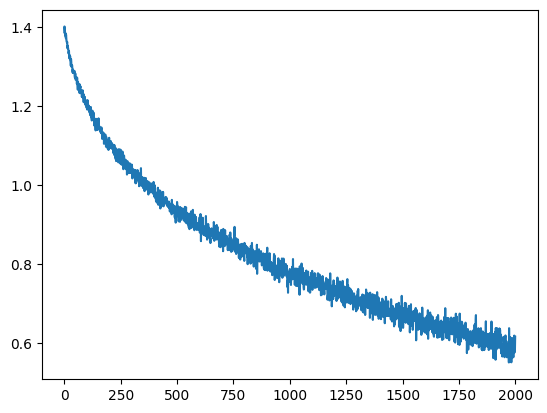

In [13]:
plt.plot(list(range(EPOCHS)), losses)

# Eval Model with Dev Data

In [ ]:
@torch.no_grad()
def calc_loss(inputs, labels):
    embed = C[inputs]
    joined_embed = embed.view(embed.shape[0], embed.shape[1] * embed.shape[2])
    preact = joined_embed @ weights1
    batch_norm_preact = batch_norm_gain * ((preact - batch_norm_running_mean) / batch_norm_running_std) + batch_norm_bias
    layer1_out = torch.tanh(batch_norm_preact)
    logits = layer1_out @ weights2 + bias2
    loss = tfunc.cross_entropy(logits, labels)
    return loss

# Train and Dev are too big, they need to be evaled in chunks
BATCH_SIZE = 2056
m_train_loss = 0
for batch_idx in range(0, train_inputs.shape[0] // 10, BATCH_SIZE):
    end_idx = min(batch_idx + BATCH_SIZE, train_inputs.shape[0] // 10)
    m_train_loss += calc_loss(
        train_inputs[batch_idx:end_idx],
        train_labels[batch_idx:end_idx]
    ).item() * BATCH_SIZE
m_train_loss /= BATCH_SIZE

m_dev_loss = 0
for batch_idx in range(0, dev_inputs.shape[0], BATCH_SIZE):
    end_idx = min(batch_idx + BATCH_SIZE, dev_inputs.shape[0])
    m_dev_loss += calc_loss(
        dev_inputs[batch_idx:end_idx],
        dev_labels[batch_idx:end_idx]
    ).item()
m_dev_loss /= BATCH_SIZE

print(f"Test loss: {m_train_loss}")
print(f"Dev loss: {m_dev_loss}")

454515


In [ ]:
# Best train loss: N/A
# Best dev loss: N/A

# Sample from the model

In [18]:
NUM_SAMPLES = 20
g = torch.Generator(device=torch_device).manual_seed(2147483647 + 10)
for _ in range(NUM_SAMPLES): 
    out = []
    context = [0] * BLOCK_SIZE
    while True:
        embed = C[torch.tensor([context])]
        joined_embed = embed.view(embed.shape[0], embed.shape[1] * embed.shape[2])
        preact = joined_embed @ weights1
        batch_norm_preact = batch_norm_gain * ((preact - batch_norm_running_mean) / batch_norm_running_std) + batch_norm_bias
        layer1_out = torch.tanh(batch_norm_preact)
        logits = layer1_out @ weights2 + bias2
        probs = tfunc.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        if ix == 1: break
        out.append(ix)
  
    print(''.join(indx_to_char[i] for i in out)) # decode and print the generated word

5mmmmfffrrrrrllllllc7ccddd      iaawttsneeeeeee   eeeeppp
5HmmmfffrrrKMllllllk7d
A::nnnnn
5:1v1ooooWkkklIssDuuueeeRddeeb  jkk
5mmmmfffrrrrrllllllc7c
5mmmmfffrrrrrllllllc7c
Wv2-nng:mHUEWtCk
u Nhheuu5Snnnn
AAHHHHHHiiiiTddddiiS
5:1v1ooooF5NGGDANDumkAeeaaU      ooi6l kittasa      riNe tMu   iiiiibqwreetlMN   nnn nsuJcfttlsFtl  aiddneeee   huaha en
AAHHHHHHGGAAAHHHHHHHHHHHHHROOOFFVOss-
5::AxHHb
5Hmm1f-       aaaaKK
5:1vLooo:NOkGTItNelluueeeoooohXi  rEEEHAw  o absh Ehrmmm0
AvHHHHHHGOOGWWJMMHIHHGGOhii5s:dNBF  OBttta      
5mmmmWfffcbG       poooNNo   uaajcmmmlnngfeefoig   iiulbtwGMa 
5:1v1MMA
AAmmm::L1IElFWHoo   7p44agNhDnnwPe
AAHHHHHHGGA:uusHHHHHHHGHRwwOO9iiiOsi-
pvvHHHHbEOOGWHJMMAcH9H
rr-AARddsWriaHHtuu
tl
A3HHHHHWGii:TddHNlEHHHH

